Generacija   1: najbolja dužina = 18.926 | putanja = A -> C -> E -> D -> G -> F -> B
Generacija  11: najbolja dužina = 18.926 | putanja = A -> C -> E -> D -> G -> F -> B
Generacija  21: najbolja dužina = 18.926 | putanja = A -> C -> E -> D -> G -> F -> B
Generacija  31: najbolja dužina = 18.926 | putanja = A -> C -> E -> D -> G -> F -> B
Generacija  41: najbolja dužina = 18.926 | putanja = A -> C -> E -> D -> G -> F -> B
Generacija  51: najbolja dužina = 18.926 | putanja = A -> C -> E -> D -> G -> F -> B
Generacija  61: najbolja dužina = 18.926 | putanja = A -> C -> E -> D -> G -> F -> B
Generacija  71: najbolja dužina = 18.926 | putanja = A -> C -> E -> D -> G -> F -> B
Generacija  81: najbolja dužina = 18.926 | putanja = A -> C -> E -> D -> G -> F -> B
Generacija  91: najbolja dužina = 18.926 | putanja = A -> C -> E -> D -> G -> F -> B
Generacija 101: najbolja dužina = 18.926 | putanja = A -> C -> E -> D -> G -> F -> B
Generacija 111: najbolja dužina = 18.926 | putanja = A -> C -> E 

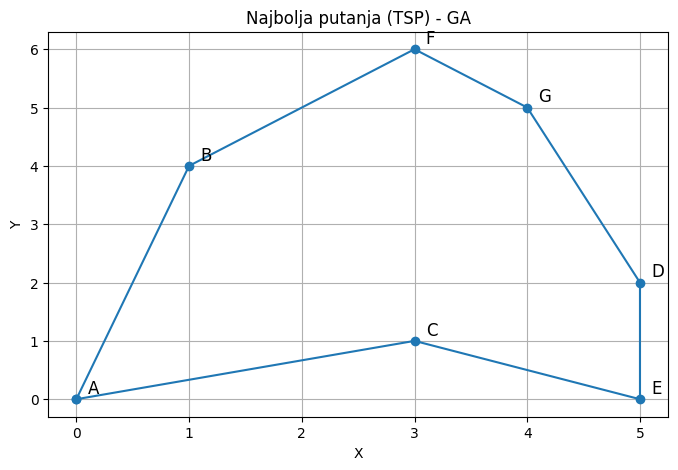

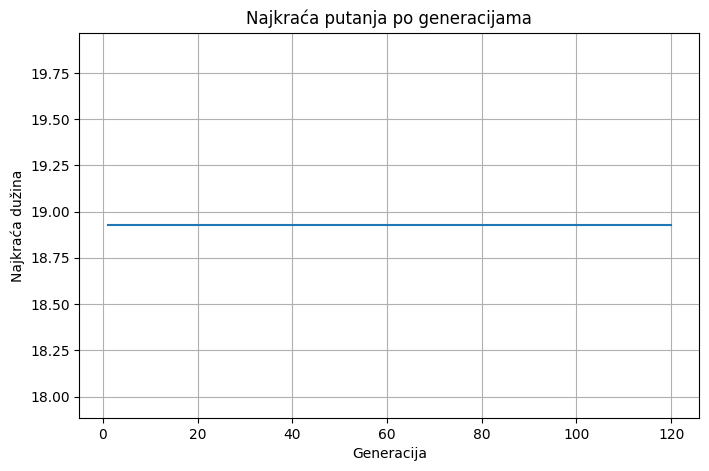

In [7]:
import random
import math
import numpy as np
import matplotlib.pyplot as plt

# =====================
# PODACI O GRADOVIMA
# =====================
cities = {
    'A': (0, 0),
    'B': (1, 4),
    'C': (3, 1),
    'D': (5, 2),
    'E': (5, 0),
    'F': (3, 6),
    'G': (4, 5),
}

city_names = list(cities.keys())

# =====================
# PARAMETRI GA
# =====================
POP_SIZE = 105
GENERATIONS = 120
MUTATION_PROB = 0.2
ELITISM_RATE = 0.09

# Ukrštanje u dve tačke (2,5) -> ovde tretiramo kao indekse koji su UKLJUČENI u segment
CUT1, CUT2 = 2, 5

# =====================
# POMOĆNE FUNKCIJE
# =====================
def distance(c1, c2):
    x1, y1 = cities[c1]
    x2, y2 = cities[c2]
    return math.sqrt((x2 - x1) ** 2 + (y2 - y1) ** 2)

def total_distance(route):
    # Zatvaramo turu: poslednji grad ide nazad na prvi
    dist = 0.0
    for i in range(len(route)):
        dist += distance(route[i], route[(i + 1) % len(route)])
    return dist

def fitness(route):
    # Što je kraća putanja, to je veći fitness
    return 1.0 / total_distance(route)

def create_population():
    population = []
    for _ in range(POP_SIZE):
        ind = city_names[:]
        random.shuffle(ind)
        population.append(ind)
    return population

def roulette_selection(population):
    # Ruletska selekcija: verovatnoća biranja proporcionalna fitness-u
    fits = np.array([fitness(ind) for ind in population], dtype=float)
    probs = fits / fits.sum()
    idx = np.random.choice(len(population), p=probs)
    return population[idx]

# =====================
# UKRŠTANJE (2 tačke: 2 i 5)
# =====================
def two_point_crossover(parent1, parent2, cut1=CUT1, cut2=CUT2):
    # Napomena: koristimo "order" popunjavanje da ostane permutacija (bez duplikata)
    if cut1 > cut2:
        cut1, cut2 = cut2, cut1

    child = [None] * len(parent1)

    # Prepišemo segment iz parent1: indeksi 2..5 (uključivo)
    child[cut1:cut2 + 1] = parent1[cut1:cut2 + 1]

    # Ostatak popunjavamo redosledom iz parent2, preskačemo gene koji već postoje
    ptr = 0
    for gene in parent2:
        if gene not in child:
            while child[ptr] is not None:
                ptr += 1
            child[ptr] = gene

    return child

# =====================
# MUTACIJA: ROTACIJA GENA (p = 0.2)
# =====================
def rotation_mutation(route):
    # Rotacija segmenta čuva permutaciju, samo "ciklički pomeri" deo hromozoma
    if random.random() < MUTATION_PROB:
        i, j = sorted(random.sample(range(len(route)), 2))
        segment = route[i:j + 1]

        # Rotacija udesno za 1: [a,b,c] -> [c,a,b]
        segment = [segment[-1]] + segment[:-1]
        route[i:j + 1] = segment

    return route

# =====================
# GLAVNI GENETSKI ALGORITAM
# =====================
def genetic_algorithm(seed=1337):
    # Seed da dobiješ ponovljive rezultate (možeš promeniti ili ukloniti)
    random.seed(seed)
    np.random.seed(seed)

    population = create_population()

    best_distances = []
    best_routes = []

    elite_count = max(1, int(ELITISM_RATE * POP_SIZE))  # 9% od 105 -> 9 (floor)

    for gen in range(GENERATIONS):
        # Sortiramo po dužini (manje je bolje)
        population = sorted(population, key=total_distance)

        best_route_gen = population[0]
        best_dist_gen = total_distance(best_route_gen)

        best_distances.append(best_dist_gen)
        best_routes.append(best_route_gen.copy())

        # Elitizam: prenesi najboljih 9% direktno
        new_population = population[:elite_count]

        # Popuni ostatak populacije selekcijom + ukrštanjem + mutacijom
        while len(new_population) < POP_SIZE:
            p1 = roulette_selection(population)
            p2 = roulette_selection(population)
            child = two_point_crossover(p1, p2)
            child = rotation_mutation(child)
            new_population.append(child)

        population = new_population

        # Mali ispis da vidiš progres (nije obavezno, ali pomaže)
        if gen % 10 == 0 or gen == GENERATIONS - 1:
            print(f"Generacija {gen + 1:3d}: najbolja dužina = {best_dist_gen:.3f} | putanja = {' -> '.join(best_route_gen)}")

    # Finalno najbolje rešenje iz poslednje populacije
    population = sorted(population, key=total_distance)
    best = population[0]
    return best, total_distance(best), best_distances, best_routes

# =====================
# POKRETANJE
# =====================
best_route, best_dist, best_distances, best_routes = genetic_algorithm(seed=7)

print("\nNAJBOLJE KONAČNO REŠENJE:")
print("Putanja:", " -> ".join(best_route))
print("Ukupna dužina puta:", round(best_dist, 3))

# =====================
# GRAFIK PUTANJE (najbolja)
# =====================
x = [cities[c][0] for c in best_route] + [cities[best_route[0]][0]]
y = [cities[c][1] for c in best_route] + [cities[best_route[0]][1]]

plt.figure(figsize=(8, 5))
plt.plot(x, y, 'o-')
for c in best_route:
    plt.text(cities[c][0] + 0.1, cities[c][1] + 0.1, c, fontsize=12)
plt.title("Najbolja putanja (TSP) - GA")
plt.xlabel("X")
plt.ylabel("Y")
plt.grid(True)
plt.show()

# =====================
# GRAFIK NAPREDOVANJA
# =====================
plt.figure(figsize=(8, 5))
plt.plot(range(1, GENERATIONS + 1), best_distances)
plt.title("Najkraća putanja po generacijama")
plt.xlabel("Generacija")
plt.ylabel("Najkraća dužina")
plt.grid(True)
plt.show()


In [8]:
import itertools
import math

cities = {
    'A': (0, 0),
    'B': (1, 4),
    'C': (3, 1),
    'D': (5, 2),
    'E': (5, 0),
    'F': (3, 6),
    'G': (4, 5),
}

def dist(c1, c2):
    x1, y1 = cities[c1]
    x2, y2 = cities[c2]
    return math.hypot(x2 - x1, y2 - y1)

def tour_len(route):
    return sum(dist(route[i], route[(i+1) % len(route)]) for i in range(len(route)))

best_route = None
best_len = float('inf')

# Fiksiramo start na 'A' da ne računamo rotacije kao različite
others = [c for c in cities if c != 'A']
for perm in itertools.permutations(others):
    route = ('A',) + perm
    L = tour_len(route)
    if L < best_len:
        best_len = L
        best_route = route

print("OPTIMUM (brute force):", " -> ".join(best_route))
print("Dužina:", best_len)

OPTIMUM (brute force): A -> B -> F -> G -> D -> E -> C
Dužina: 18.926369610573495
